Imports

In [2]:
import json
import gzip
import os
import re
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score, mean_squared_error
import pickle
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


Data Loading

In [3]:
import json
import random

def load_json(filepath, max_samples=13000):
    records = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:   # works if file is JSONL (one JSON per line)
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
                if 'reviewText' in obj and 'overall' in obj:
                    records.append(obj)
            except:
                continue
            
            if len(records) >= max_samples:
                break
    
    return records


# file paths
beauty_path = 'Dataset/Beauty_5.json'
phones_path = 'Dataset/Cell_Phones_and_Accessories_5.json'
sports_path = 'Dataset/Sports_and_Outdoors_5.json'

print('Loading Beauty...')
beauty_data = load_json(beauty_path, 13000)
print(f'Beauty: {len(beauty_data)}')

print('Loading Cell Phones...')
phones_data = load_json(phones_path, 13000)
print(f'Phones: {len(phones_data)}')

print('Loading Sports...')
sports_data = load_json(sports_path, 13000)
print(f'Sports: {len(sports_data)}')

all_data = beauty_data + phones_data + sports_data
random.shuffle(all_data)

print(f'Total: {len(all_data)}')

Loading Beauty...
Beauty: 13000
Loading Cell Phones...
Phones: 13000
Loading Sports...
Sports: 13000
Total: 39000


Preprocessing

In [4]:
def clean_text(text):
    # basic text cleaning
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text):
    # whitespace tokenization
    return text.split()

def map_sentiment(rating):
    # map rating to 3 classes
    if rating <= 2:
        return 0
    elif rating == 3:
        return 1
    else:
        return 2

def review_length_class(tokens):
    # derived feature: review length bucket
    # 0=short(<20), 1=medium(20-60), 2=long(>60)
    n = len(tokens)
    if n < 20:
        return 0
    elif n <= 60:
        return 1
    else:
        return 2

# clean and tokenize all samples
samples = []
for item in all_data:
    text   = clean_text(item['reviewText'])
    tokens = tokenize(text)
    if len(tokens) < 3:
        continue
    sentiment   = map_sentiment(int(item['overall']))
    len_class   = review_length_class(tokens)
    samples.append({'tokens': tokens, 'sentiment': sentiment, 'len_class': len_class})

random.shuffle(samples)
print(f'Cleaned samples: {len(samples)}')

Cleaned samples: 38948


Train Val Test Split

In [5]:
# split 70 15 15
n = len(samples)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_samples = samples[:n_train]
val_samples   = samples[n_train:n_train + n_val]
test_samples  = samples[n_train + n_val:]

print(f'Train: {len(train_samples)}, Val: {len(val_samples)}, Test: {len(test_samples)}')

Train: 27263, Val: 5842, Test: 5843


Vocabulary

In [6]:
# build vocab from training set only
MIN_FREQ  = 3
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

counter = Counter()
for s in train_samples:
    counter.update(s['tokens'])

vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word, freq in counter.items():
    if freq >= MIN_FREQ:
        vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)
print(f'Vocab size: {VOCAB_SIZE}')

def tokens_to_ids(tokens, vocab, max_len=128):
    # convert tokens to indices with padding and truncation
    ids = [vocab.get(t, vocab[UNK_TOKEN]) for t in tokens[:max_len]]
    if len(ids) < max_len:
        ids += [vocab[PAD_TOKEN]] * (max_len - len(ids))
    return ids

MAX_LEN = 128

Vocab size: 16043


Dataset

In [7]:
class ReviewDataset(Dataset):
    def __init__(self, samples, vocab, max_len=128):
        self.data = samples
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        s = self.data[idx]
        input_ids   = tokens_to_ids(s['tokens'], self.vocab, self.max_len)
        # pad mask: 1 for real tokens, 0 for padding
        attn_mask   = [1 if x != 0 else 0 for x in input_ids]
        return (
            torch.tensor(input_ids,   dtype=torch.long),
            torch.tensor(attn_mask,   dtype=torch.float),
            torch.tensor(s['sentiment'], dtype=torch.long),
            torch.tensor(s['len_class'], dtype=torch.long)
        )

BATCH_SIZE = 64

train_ds = ReviewDataset(train_samples, vocab, MAX_LEN)
val_ds   = ReviewDataset(val_samples,   vocab, MAX_LEN)
test_ds  = ReviewDataset(test_samples,  vocab, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('Dataloaders ready')

Dataloaders ready


Transformer Architecture

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        # compute positional encodings
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # add positional encoding
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k, dropout=0.1):
        super().__init__()
        self.d_k    = d_k
        self.dropout = nn.Dropout(dropout)

    def forward(self, Q, K, V, mask=None):
        # scaled dot product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        return torch.matmul(attn, V), attn


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads
        # separate linear projections for each head
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)
        self.attention = ScaledDotProductAttention(self.d_k, dropout)
        self.dropout   = nn.Dropout(dropout)

    def split_heads(self, x):
        # reshape to (batch, heads, seq, d_k)
        B, T, D = x.size()
        return x.view(B, T, self.num_heads, self.d_k).transpose(1, 2)

    def forward(self, x, mask=None):
        B, T, _ = x.size()
        Q = self.split_heads(self.W_Q(x))
        K = self.split_heads(self.W_K(x))
        V = self.split_heads(self.W_V(x))
        if mask is not None:
            mask = mask.unsqueeze(1).unsqueeze(2)  # broadcast over heads
        out, _ = self.attention(Q, K, V, mask)
        # combine heads
        out = out.transpose(1, 2).contiguous().view(B, T, self.num_heads * self.d_k)
        return self.W_O(out)


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))


class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn    = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff      = FeedForward(d_model, d_ff, dropout)
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # self attention with residual
        x = self.norm1(x + self.dropout(self.attn(x, mask)))
        # feedforward with residual
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x


class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers,
                 d_ff, max_len, num_sentiment_classes, num_len_classes, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        self.layers    = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        # task heads
        self.sentiment_head = nn.Linear(d_model, num_sentiment_classes)
        self.len_head       = nn.Linear(d_model, num_len_classes)

    def forward(self, input_ids, attn_mask=None):
        # embed and encode
        x = self.embedding(input_ids)
        x = self.pos_enc(x)
        for layer in self.layers:
            x = layer(x, attn_mask)
        x = self.norm(x)
        # mean pooling over non-padding tokens
        if attn_mask is not None:
            mask_expanded = attn_mask.unsqueeze(-1).float()
            pooled = (x * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)
        else:
            pooled = x.mean(dim=1)
        # classification heads
        sentiment_logits = self.sentiment_head(pooled)
        len_logits       = self.len_head(pooled)
        return sentiment_logits, len_logits, pooled

print('Architecture defined')

Architecture defined


Model Init

In [9]:
# model hyperparameters
D_MODEL    = 128
NUM_HEADS  = 4
NUM_LAYERS = 2
D_FF       = 256
DROPOUT    = 0.1

model = TransformerEncoder(
    vocab_size            = VOCAB_SIZE,
    d_model               = D_MODEL,
    num_heads             = NUM_HEADS,
    num_layers            = NUM_LAYERS,
    d_ff                  = D_FF,
    max_len               = MAX_LEN,
    num_sentiment_classes = 3,
    num_len_classes       = 3,
    dropout               = DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {total_params:,}')

Trainable params: 2,319,494


Training Setup

In [10]:
# compute class weights for sentiment (handle imbalance)
sent_counts = Counter([s['sentiment'] for s in train_samples])
total_sent  = sum(sent_counts.values())
sent_weights = torch.tensor(
    [total_sent / (3 * sent_counts[i]) for i in range(3)], dtype=torch.float
).to(device)

len_counts = Counter([s['len_class'] for s in train_samples])
total_len  = sum(len_counts.values())
len_weights = torch.tensor(
    [total_len / (3 * len_counts[i]) for i in range(3)], dtype=torch.float
).to(device)

criterion_sent = nn.CrossEntropyLoss(weight=sent_weights)
criterion_len  = nn.CrossEntropyLoss(weight=len_weights)

EPOCHS = 3
LR     = 3e-4
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print('Training setup complete')
print(f'Sentiment class weights: {sent_weights.cpu().numpy()}')
print(f'Length class weights:    {len_weights.cpu().numpy()}')

Training setup complete
Sentiment class weights: [2.8740249  3.4331949  0.42358845]
Length class weights:    [22.273693    0.6280784   0.73370475]


Training Loop

In [11]:
def run_epoch(model, loader, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss = 0
    sent_preds, sent_labels = [], []
    len_preds,  len_labels  = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for input_ids, attn_mask, sentiment, len_class in loader:
            input_ids  = input_ids.to(device)
            attn_mask  = attn_mask.to(device)
            sentiment  = sentiment.to(device)
            len_class  = len_class.to(device)

            sent_logits, len_logits, _ = model(input_ids, attn_mask)

            loss_sent = criterion_sent(sent_logits, sentiment)
            loss_len  = criterion_len(len_logits,   len_class)
            # equal weight combined loss
            loss = loss_sent + loss_len

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item()
            sent_preds.extend(sent_logits.argmax(dim=1).cpu().tolist())
            sent_labels.extend(sentiment.cpu().tolist())
            len_preds.extend(len_logits.argmax(dim=1).cpu().tolist())
            len_labels.extend(len_class.cpu().tolist())

    avg_loss  = total_loss / len(loader)
    sent_f1   = f1_score(sent_labels, sent_preds, average='macro', zero_division=0)
    len_f1    = f1_score(len_labels,  len_preds,  average='macro', zero_division=0)
    return avg_loss, sent_f1, len_f1


train_losses, val_losses       = [], []
train_sent_f1s, val_sent_f1s   = [], []
train_len_f1s,  val_len_f1s    = [], []

best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_sf1, tr_lf1 = run_epoch(model, train_loader, optimizer, train=True)
    vl_loss, vl_sf1, vl_lf1 = run_epoch(model, val_loader,   train=False)
    scheduler.step()

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    train_sent_f1s.append(tr_sf1)
    val_sent_f1s.append(vl_sf1)
    train_len_f1s.append(tr_lf1)
    val_len_f1s.append(vl_lf1)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), 'best_encoder.pt')

    print(f'Epoch {epoch:02d} | '
          f'Train Loss: {tr_loss:.4f} | Val Loss: {vl_loss:.4f} | '
          f'Train Sent F1: {tr_sf1:.4f} | Val Sent F1: {vl_sf1:.4f} | '
          f'Train Len F1: {tr_lf1:.4f} | Val Len F1: {vl_lf1:.4f}')

Epoch 01 | Train Loss: 1.2266 | Val Loss: 1.0810 | Train Sent F1: 0.3337 | Val Sent F1: 0.3674 | Train Len F1: 0.8580 | Val Len F1: 0.9434
Epoch 02 | Train Loss: 1.0137 | Val Loss: 0.9596 | Train Sent F1: 0.4310 | Val Sent F1: 0.4553 | Train Len F1: 0.9545 | Val Len F1: 0.9522
Epoch 03 | Train Loss: 0.9305 | Val Loss: 0.9469 | Train Sent F1: 0.4783 | Val Sent F1: 0.4644 | Train Len F1: 0.9703 | Val Len F1: 0.9651


Learning Curves

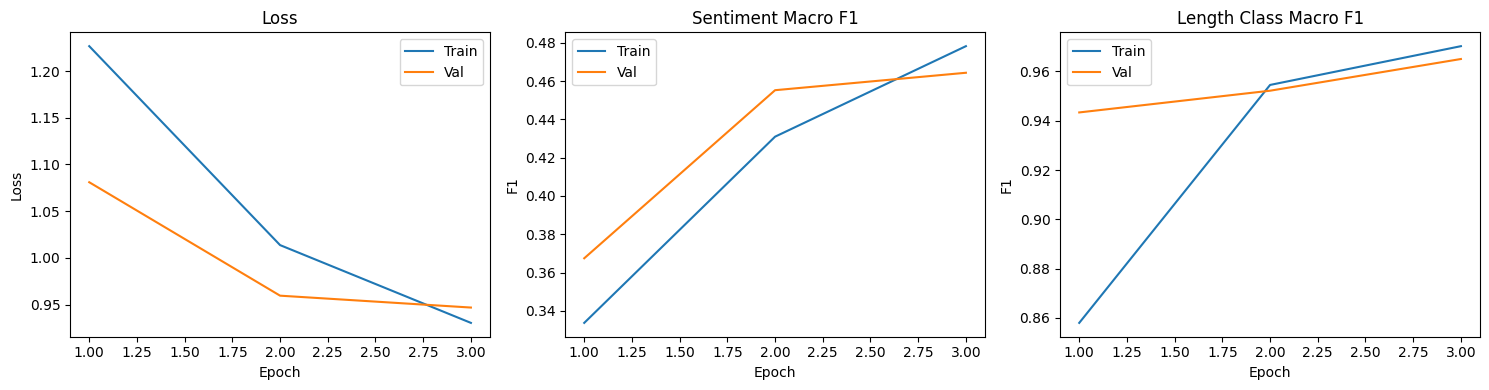

Learning curves saved


In [12]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# loss curve
axes[0].plot(epochs_range, train_losses, label='Train')
axes[0].plot(epochs_range, val_losses,   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# sentiment f1 curve
axes[1].plot(epochs_range, train_sent_f1s, label='Train')
axes[1].plot(epochs_range, val_sent_f1s,   label='Val')
axes[1].set_title('Sentiment Macro F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].legend()

# length class f1 curve
axes[2].plot(epochs_range, train_len_f1s, label='Train')
axes[2].plot(epochs_range, val_len_f1s,   label='Val')
axes[2].set_title('Length Class Macro F1')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1')
axes[2].legend()

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=100)
plt.show()
print('Learning curves saved')

Evaluation

In [13]:
# load best model
model.load_state_dict(torch.load('best_encoder.pt', map_location=device))
model.eval()

all_sent_preds, all_sent_labels = [], []
all_len_preds,  all_len_labels  = [], []

with torch.no_grad():
    for input_ids, attn_mask, sentiment, len_class in test_loader:
        input_ids = input_ids.to(device)
        attn_mask = attn_mask.to(device)

        sent_logits, len_logits, _ = model(input_ids, attn_mask)

        all_sent_preds.extend(sent_logits.argmax(dim=1).cpu().tolist())
        all_sent_labels.extend(sentiment.tolist())
        all_len_preds.extend(len_logits.argmax(dim=1).cpu().tolist())
        all_len_labels.extend(len_class.tolist())

print('Sentiment Classification Report')
print(classification_report(
    all_sent_labels, all_sent_preds,
    target_names=['Negative', 'Neutral', 'Positive']
))

print('\nReview Length Class Report')
print(classification_report(
    all_len_labels, all_len_preds,
    target_names=['Short', 'Medium', 'Long']
))

Sentiment Classification Report
              precision    recall  f1-score   support

    Negative       0.28      0.67      0.39       687
     Neutral       0.21      0.36      0.27       531
    Positive       0.93      0.65      0.77      4625

    accuracy                           0.63      5843
   macro avg       0.47      0.56      0.47      5843
weighted avg       0.79      0.63      0.68      5843


Review Length Class Report
              precision    recall  f1-score   support

       Short       0.89      0.94      0.92        90
      Medium       1.00      0.99      0.99      3072
        Long       1.00      1.00      1.00      2681

    accuracy                           0.99      5843
   macro avg       0.96      0.98      0.97      5843
weighted avg       0.99      0.99      0.99      5843



Save Embeddings

In [14]:
# generate and save embeddings for all test samples
model.eval()
all_embeddings = []
all_meta       = []

with torch.no_grad():
    for batch_idx, (input_ids, attn_mask, sentiment, len_class) in enumerate(test_loader):
        input_ids = input_ids.to(device)
        attn_mask = attn_mask.to(device)

        _, _, pooled = model(input_ids, attn_mask)
        all_embeddings.append(pooled.cpu().numpy())

        for i in range(len(sentiment)):
            idx = batch_idx * BATCH_SIZE + i
            if idx < len(test_samples):
                all_meta.append({
                    'sentiment':  sentiment[i].item(),
                    'len_class':  len_class[i].item(),
                    'tokens':     test_samples[idx]['tokens']
                })

all_embeddings = np.vstack(all_embeddings)

# save embeddings to disk
np.save('review_embeddings.npy', all_embeddings)
with open('review_meta.pkl', 'wb') as f:
    pickle.dump(all_meta, f)

print(f'Embeddings shape: {all_embeddings.shape}')
print('Saved review_embeddings.npy and review_meta.pkl')

Embeddings shape: (5843, 128)
Saved review_embeddings.npy and review_meta.pkl


Save Vocab and Model

In [15]:
# save vocab for Parts B and C
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

# save model config
model_config = {
    'vocab_size':  VOCAB_SIZE,
    'd_model':     D_MODEL,
    'num_heads':   NUM_HEADS,
    'num_layers':  NUM_LAYERS,
    'd_ff':        D_FF,
    'max_len':     MAX_LEN,
    'dropout':     DROPOUT
}
with open('model_config.pkl', 'wb') as f:
    pickle.dump(model_config, f)

print('Vocab, model config, and weights saved')
print('Part A complete')

Vocab, model config, and weights saved
Part A complete


# Part B: Retrieval Module

In [16]:
import sys
!{sys.executable} -m pip install tqdm



[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import json
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

In [18]:
# load vocab and model config from part A
with open('vocab.pkl', 'rb') as f:
    vocab = pickle.load(f)

with open('model_config.pkl', 'rb') as f:
    model_config = pickle.load(f)

VOCAB_SIZE  = model_config['vocab_size']
D_MODEL     = model_config['d_model']
NUM_HEADS   = model_config['num_heads']
NUM_LAYERS  = model_config['num_layers']
D_FF        = model_config['d_ff']
MAX_LEN     = model_config['max_len']
DROPOUT     = model_config['dropout']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Vocab size:', VOCAB_SIZE)
print('Device:', device)

Vocab size: 16043
Device: cpu


### Encoder Definition

In [19]:
# same architecture as part A
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k, dropout=0.1):
        super().__init__()
        self.d_k     = d_k
        self.dropout = nn.Dropout(dropout)

    def forward(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        return torch.matmul(attn, V), attn


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)
        self.attention = ScaledDotProductAttention(self.d_k, dropout)
        self.dropout   = nn.Dropout(dropout)

    def split_heads(self, x):
        B, T, D = x.size()
        return x.view(B, T, self.num_heads, self.d_k).transpose(1, 2)

    def forward(self, x, mask=None):
        B, T, _ = x.size()
        Q = self.split_heads(self.W_Q(x))
        K = self.split_heads(self.W_K(x))
        V = self.split_heads(self.W_V(x))
        if mask is not None:
            mask = mask.unsqueeze(1).unsqueeze(2)
        out, _ = self.attention(Q, K, V, mask)
        out = out.transpose(1, 2).contiguous().view(B, T, self.num_heads * self.d_k)
        return self.W_O(out)


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))


class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn    = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff      = FeedForward(d_model, d_ff, dropout)
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.dropout(self.attn(x, mask)))
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x


class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers,
                 d_ff, max_len, num_sentiment_classes=3, num_len_classes=3, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        self.layers    = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm           = nn.LayerNorm(d_model)
        self.sentiment_head = nn.Linear(d_model, num_sentiment_classes)
        self.len_head       = nn.Linear(d_model, num_len_classes)

    def forward(self, input_ids, attn_mask=None):
        x = self.embedding(input_ids)
        x = self.pos_enc(x)
        for layer in self.layers:
            x = layer(x, attn_mask)
        x = self.norm(x)
        if attn_mask is not None:
            mask_expanded = attn_mask.unsqueeze(-1).float()
            pooled = (x * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)
        else:
            pooled = x.mean(dim=1)
        sentiment_logits = self.sentiment_head(pooled)
        len_logits       = self.len_head(pooled)
        return sentiment_logits, len_logits, pooled

print('Encoder architecture defined')

Encoder architecture defined


In [20]:
# load best encoder weights
model = TransformerEncoder(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    max_len=MAX_LEN,
    dropout=DROPOUT
).to(device)

model.load_state_dict(torch.load('best_encoder.pt', map_location=device))
model.eval()
print('Encoder weights loaded')

Encoder weights loaded


### Data Loading

In [21]:
import gzip
import re
import random
from collections import Counter

random.seed(42)

def load_gz_json(filepath, max_samples=13000):
    records = []
    with gzip.open(filepath, 'rt', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
                if 'reviewText' in obj and 'overall' in obj:
                    records.append(obj)
            except:
                continue
            if len(records) >= max_samples:
                break
    return records

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text):
    return text.split()

def map_sentiment(rating):
    if rating <= 2:
        return 0
    elif rating == 3:
        return 1
    else:
        return 2

def review_length_class(tokens):
    n = len(tokens)
    if n < 20:
        return 0
    elif n <= 60:
        return 1
    else:
        return 2

import json
import random

def load_json(filepath, max_samples=13000):
    records = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:   # works if file is JSONL (one JSON per line)
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
                if 'reviewText' in obj and 'overall' in obj:
                    records.append(obj)
            except:
                continue
            
            if len(records) >= max_samples:
                break
    
    return records


# file paths
beauty_path = 'Dataset/Beauty_5.json'
phones_path = 'Dataset/Cell_Phones_and_Accessories_5.json'
sports_path = 'Dataset/Sports_and_Outdoors_5.json'

print('Loading Beauty...')
beauty_data = load_json(beauty_path, 13000)
print(f'Beauty: {len(beauty_data)}')

print('Loading Cell Phones...')
phones_data = load_json(phones_path, 13000)
print(f'Phones: {len(phones_data)}')

print('Loading Sports...')
sports_data = load_json(sports_path, 13000)
print(f'Sports: {len(sports_data)}')


all_data = beauty_data + phones_data + sports_data
random.shuffle(all_data)

samples = []
for item in all_data:
    text   = clean_text(item['reviewText'])
    tokens = tokenize(text)
    if len(tokens) < 3:
        continue
    sentiment = map_sentiment(int(item['overall']))
    len_class = review_length_class(tokens)
    samples.append({'tokens': tokens, 'sentiment': sentiment, 'len_class': len_class})

random.shuffle(samples)

# same 70/15/15 split as part A
n       = len(samples)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_samples = samples[:n_train]
val_samples   = samples[n_train:n_train + n_val]
test_samples  = samples[n_train + n_val:]

print(f'Train: {len(train_samples)}, Val: {len(val_samples)}, Test: {len(test_samples)}')

Loading Beauty...
Beauty: 13000
Loading Cell Phones...
Phones: 13000
Loading Sports...
Sports: 13000
Train: 27263, Val: 5842, Test: 5843


### Embedding Storage and Indexing


In [22]:
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'
BATCH_SIZE = 128

def tokens_to_ids(tokens, vocab, max_len=128):
    ids = [vocab.get(t, vocab[UNK_TOKEN]) for t in tokens[:max_len]]
    if len(ids) < max_len:
        ids += [vocab[PAD_TOKEN]] * (max_len - len(ids))
    return ids

class ReviewDataset(Dataset):
    def __init__(self, samples, vocab, max_len=128):
        self.data    = samples
        self.vocab   = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        s         = self.data[idx]
        input_ids = tokens_to_ids(s['tokens'], self.vocab, self.max_len)
        attn_mask = [1 if x != 0 else 0 for x in input_ids]
        return (
            torch.tensor(input_ids,      dtype=torch.long),
            torch.tensor(attn_mask,      dtype=torch.float),
            torch.tensor(s['sentiment'], dtype=torch.long),
            torch.tensor(s['len_class'], dtype=torch.long)
        )

print('Dataset class ready')

Dataset class ready


In [23]:
# encode all training samples and store embeddings
train_ds     = ReviewDataset(train_samples, vocab, MAX_LEN)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model.eval()
train_embeddings_list = []

with torch.no_grad():
    for input_ids, attn_mask, _, _ in tqdm(train_loader, desc='Encoding train corpus'):
        input_ids = input_ids.to(device)
        attn_mask = attn_mask.to(device)
        _, _, pooled = model(input_ids, attn_mask)
        train_embeddings_list.append(pooled.cpu().numpy())

train_embeddings = np.vstack(train_embeddings_list)
print(f'Train embedding matrix shape: {train_embeddings.shape}')

Encoding train corpus: 100%|██████████| 213/213 [01:10<00:00,  3.00it/s]

Train embedding matrix shape: (27263, 128)


In [24]:
# encode all test samples for query construction
test_ds     = ReviewDataset(test_samples, vocab, MAX_LEN)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

test_embeddings_list = []

with torch.no_grad():
    for input_ids, attn_mask, _, _ in tqdm(test_loader, desc='Encoding test queries'):
        input_ids = input_ids.to(device)
        attn_mask = attn_mask.to(device)
        _, _, pooled = model(input_ids, attn_mask)
        test_embeddings_list.append(pooled.cpu().numpy())

test_embeddings = np.vstack(test_embeddings_list)
print(f'Test embedding matrix shape: {test_embeddings.shape}')

Encoding test queries: 100%|██████████| 46/46 [00:19<00:00,  2.31it/s]

Test embedding matrix shape: (5843, 128)


In [25]:
# save train corpus index to disk
os.makedirs('retrieval_store', exist_ok=True)

np.save('retrieval_store/train_embeddings.npy', train_embeddings)
np.save('retrieval_store/test_embeddings.npy',  test_embeddings)

with open('retrieval_store/train_samples_index.pkl', 'wb') as f:
    pickle.dump(train_samples, f)

with open('retrieval_store/test_samples_index.pkl', 'wb') as f:
    pickle.dump(test_samples, f)

print('Index saved to retrieval_store/')

Index saved to retrieval_store/


### Query Construction

In [26]:
def build_query_vector(tokens, model, vocab, max_len, device):
    # encode a single review into a query vector
    input_ids = tokens_to_ids(tokens, vocab, max_len)
    attn_mask = [1 if x != 0 else 0 for x in input_ids]
    id_tensor   = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)
    mask_tensor = torch.tensor(attn_mask, dtype=torch.float).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        _, _, pooled = model(id_tensor, mask_tensor)
    return pooled.cpu().numpy().squeeze(0)

# verify query vector shape
sample_vec = build_query_vector(test_samples[0]['tokens'], model, vocab, MAX_LEN, device)
print(f'Query vector shape: {sample_vec.shape}')

Query vector shape: (128,)


### Similarity Search

In [27]:
def normalize_rows(matrix):
    # l2 normalize each row
    norms = np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-9
    return matrix / norms

# precompute normalized train embeddings for fast retrieval
train_embeddings_norm = normalize_rows(train_embeddings)

def retrieve_top_k(query_vec, corpus_norm, corpus_samples, k=3):
    # cosine similarity via dot product on normalized vectors
    q_norm  = query_vec / (np.linalg.norm(query_vec) + 1e-9)
    scores  = corpus_norm @ q_norm
    top_idx = np.argsort(scores)[::-1][:k]
    results = []
    for idx in top_idx:
        results.append({
            'score':     float(scores[idx]),
            'tokens':    corpus_samples[idx]['tokens'],
            'sentiment': corpus_samples[idx]['sentiment'],
            'len_class': corpus_samples[idx]['len_class'],
            'index':     int(idx)
        })
    return results

print('Retrieval function ready')

Retrieval function ready


In [28]:
K = 3  # number of retrieved examples; k=3 balances relevance and context length

# batch cosine similarity for all test queries at once
test_embeddings_norm = normalize_rows(test_embeddings)

# all scores: (n_test, n_train)
all_scores = test_embeddings_norm @ train_embeddings_norm.T

# retrieve top-k for every test sample
all_retrieved = []
for i in range(len(test_samples)):
    top_idx = np.argsort(all_scores[i])[::-1][:K]
    retrieved = []
    for idx in top_idx:
        retrieved.append({
            'score':     float(all_scores[i][idx]),
            'tokens':    train_samples[idx]['tokens'],
            'sentiment': train_samples[idx]['sentiment'],
            'len_class': train_samples[idx]['len_class'],
            'index':     int(idx)
        })
    all_retrieved.append(retrieved)

print(f'Retrieved top-{K} for {len(all_retrieved)} test queries')

Retrieved top-3 for 5843 test queries


### Retrieval Quality Analysis

In [29]:
SENTIMENT_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
LEN_MAP       = {0: 'Short', 1: 'Medium', 2: 'Long'}

def show_retrieval(query_sample, retrieved, query_idx):
    print(f'Query {query_idx}')
    print(f'  Sentiment : {SENTIMENT_MAP[query_sample["sentiment"]]}')
    print(f'  Length    : {LEN_MAP[query_sample["len_class"]]}')
    print(f'  Text      : {" ".join(query_sample["tokens"][:25])}...')
    print(f'  Retrieved:')
    for rank, r in enumerate(retrieved):
        match = 'YES' if r['sentiment'] == query_sample['sentiment'] else 'NO'
        print(f'    Rank {rank+1} | Score: {r["score"]:.4f} | '
              f'Sentiment: {SENTIMENT_MAP[r["sentiment"]]} (match={match}) | '
              f'Text: {" ".join(r["tokens"][:20])}...')
    print()

# show 5 example queries
for i in [0, 1, 2, 3, 4]:
    show_retrieval(test_samples[i], all_retrieved[i], i)

Query 0
  Sentiment : Positive
  Length    : Medium
  Text      : this is my second one of these devices the first is still working fine i wanted another to leave on some devices for longer periods...
  Retrieved:
    Rank 1 | Score: 0.9808 | Sentiment: Positive (match=YES) | Text: i purchased a couple of these for the touch screens on a comexi nexus evo laminator at my job and...
    Rank 2 | Score: 0.9805 | Sentiment: Positive (match=YES) | Text: this is one of my favorite essie polishes of all time it arrived on time and was as described brand...
    Rank 3 | Score: 0.9796 | Sentiment: Positive (match=YES) | Text: these are extremely sharp i accidentally snipped part of my hand when i was holding my bangs out to cut...

Query 1
  Sentiment : Negative
  Length    : Medium
  Text      : i guess i should have known since they are made by gamo but being unfamiliar i thought they were real targets they will work for...
  Retrieved:
    Rank 1 | Score: 0.9783 | Sentiment: Neutral (match=N

In [30]:
# compute how often retrieved docs share the same sentiment as the query
match_counts = []
for i, retrieved in enumerate(all_retrieved):
    query_sent = test_samples[i]['sentiment']
    matches    = sum(1 for r in retrieved if r['sentiment'] == query_sent)
    match_counts.append(matches / K)

mean_match = np.mean(match_counts)
print(f'Mean sentiment match rate across top-{K}: {mean_match:.4f}')
print(f'(1.0 = all retrieved docs share query sentiment)')

Mean sentiment match rate across top-3: 0.7231
(1.0 = all retrieved docs share query sentiment)


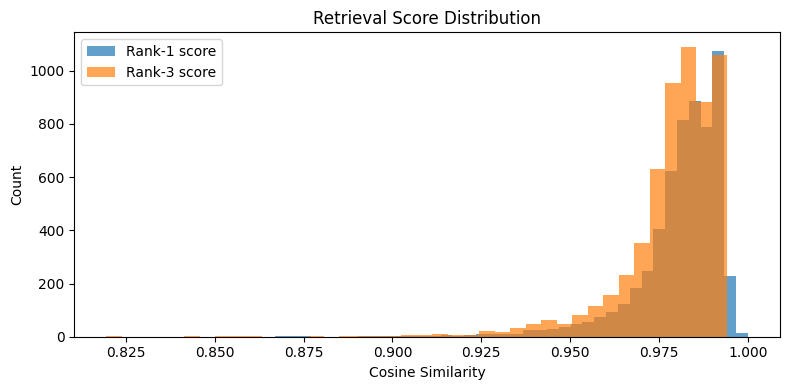

Score distribution saved


In [31]:
# distribution of top-1 cosine scores across all test queries
top1_scores = [all_retrieved[i][0]['score'] for i in range(len(test_samples))]
top3_scores = [all_retrieved[i][-1]['score'] for i in range(len(test_samples))]

plt.figure(figsize=(8, 4))
plt.hist(top1_scores, bins=40, alpha=0.7, label='Rank-1 score')
plt.hist(top3_scores, bins=40, alpha=0.7, label=f'Rank-{K} score')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.title('Retrieval Score Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('retrieval_score_dist.png', dpi=100)
plt.show()
print('Score distribution saved')

In [32]:
# analyze how k affects mean top-k score and sentiment match rate
k_values   = [1, 3, 5, 10]
mean_scores  = []
match_rates  = []

for k_val in k_values:
    top_k_idx = np.argsort(all_scores, axis=1)[:, ::-1][:, :k_val]
    scores_k  = []
    matches_k = []
    for i in range(len(test_samples)):
        q_sent = test_samples[i]['sentiment']
        idxs   = top_k_idx[i]
        scores_k.append(np.mean(all_scores[i][idxs]))
        match  = sum(1 for j in idxs if train_samples[j]['sentiment'] == q_sent)
        matches_k.append(match / k_val)
    mean_scores.append(np.mean(scores_k))
    match_rates.append(np.mean(matches_k))

print(f'{"k":>4} | {"Mean Score":>12} | {"Sent Match Rate":>16}')
print('-' * 38)
for k_val, ms, mr in zip(k_values, mean_scores, match_rates):
    print(f'{k_val:>4} | {ms:>12.4f} | {mr:>16.4f}')

   k |   Mean Score |  Sent Match Rate
--------------------------------------
   1 |       0.9809 |           0.7241
   3 |       0.9796 |           0.7231
   5 |       0.9787 |           0.7220
  10 |       0.9773 |           0.7190


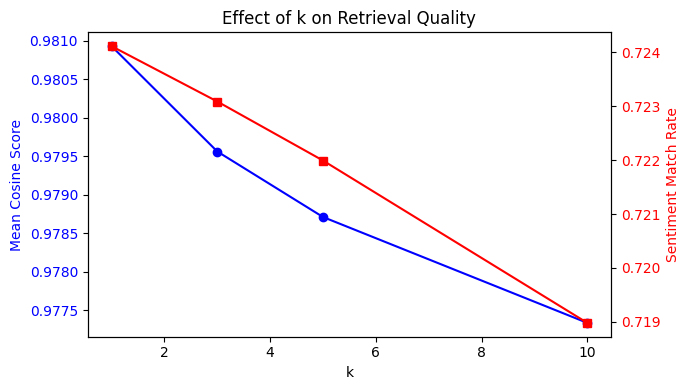

k effect plot saved


In [33]:
fig, ax1 = plt.subplots(figsize=(7, 4))

ax1.plot(k_values, mean_scores, 'b-o', label='Mean cosine score')
ax1.set_xlabel('k')
ax1.set_ylabel('Mean Cosine Score', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(k_values, match_rates, 'r-s', label='Sentiment match rate')
ax2.set_ylabel('Sentiment Match Rate', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Effect of k on Retrieval Quality')
fig.tight_layout()
plt.savefig('k_effect.png', dpi=100)
plt.show()
print('k effect plot saved')

### Context Packing for Decoder

In [34]:
def pack_context(retrieved, max_tokens_per_doc=30):
    # join tokens of each retrieved doc as context string
    parts = []
    for r in retrieved:
        text = ' '.join(r['tokens'][:max_tokens_per_doc])
        parts.append(text)
    return ' [SEP] '.join(parts)

# build retrieval output for entire test set
retrieval_output = []
for i, item in enumerate(test_samples):
    retrieval_output.append({
        'query_tokens':    item['tokens'],
        'query_sentiment': item['sentiment'],
        'query_len_class': item['len_class'],
        'retrieved':       all_retrieved[i],
        'context_string':  pack_context(all_retrieved[i])
    })

print(f'Retrieval output built for {len(retrieval_output)} test samples')
print()
print('Sample context string:')
print(retrieval_output[0]['context_string'][:200])

Retrieval output built for 5843 test samples

Sample context string:
i purchased a couple of these for the touch screens on a comexi nexus evo laminator at my job and they work great am very pleased with my purchase [SEP] this is one of my favorite essie polishes of al


In [35]:
# save full retrieval output for part C
with open('retrieval_store/retrieval_output.pkl', 'wb') as f:
    pickle.dump(retrieval_output, f)

# also save normalized embeddings for reuse
np.save('retrieval_store/train_embeddings_norm.npy', train_embeddings_norm)
np.save('retrieval_store/test_embeddings_norm.npy',  test_embeddings_norm)

print('All retrieval artifacts saved:')
print('  retrieval_store/retrieval_output.pkl')
print('  retrieval_store/train_embeddings_norm.npy')
print('  retrieval_store/test_embeddings_norm.npy')
print()
print('Part B complete')

All retrieval artifacts saved:
  retrieval_store/retrieval_output.pkl
  retrieval_store/train_embeddings_norm.npy
  retrieval_store/test_embeddings_norm.npy

Part B complete


# Part C

In [36]:
import os
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

SENT_NAMES = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
LEN_NAMES  = {0: 'Short',    1: 'Medium',  2: 'Long'}

BOS_TOKEN = '<BOS>'
EOS_TOKEN = '<EOS>'
SEP_TOKEN = '<SEP>'

# extend existing vocab with new special tokens
dec_vocab = dict(vocab)
for tok in [BOS_TOKEN, EOS_TOKEN, SEP_TOKEN]:
    if tok not in dec_vocab:
        dec_vocab[tok] = len(dec_vocab)

DEC_VOCAB_SIZE = len(dec_vocab)
id2word        = {v: k for k, v in dec_vocab.items()}

PAD_ID = dec_vocab['<PAD>']
UNK_ID = dec_vocab['<UNK>']
BOS_ID = dec_vocab[BOS_TOKEN]
EOS_ID = dec_vocab[EOS_TOKEN]

print(f'Decoder vocab size: {DEC_VOCAB_SIZE}')

Decoder vocab size: 16046


### Reference Explanations

In [37]:
# template reference explanations used as training targets
def make_explanation(sentiment_id, len_class_id):
    sent   = SENT_NAMES[sentiment_id].lower()
    length = LEN_NAMES[len_class_id].lower()
    templates = [
        f'this review expresses {sent} sentiment and is {length} in length',
        f'the reviewer conveys {sent} feedback in a {length} review',
        f'overall the review is {sent} and the writing is {length}'
    ]
    return templates[sentiment_id % 3]

train_explanations = [
    make_explanation(s['sentiment'], s['len_class']) for s in train_samples
]
test_explanations = [
    make_explanation(r['query_sentiment'], r['query_len_class'])
    for r in retrieval_output
]

print('Sample explanation:', test_explanations[0])

Sample explanation: overall the review is positive and the writing is medium


### Decoder Dataset

In [38]:
from torch.utils.data import Dataset, DataLoader

DEC_SRC_LEN = 80
DEC_TGT_LEN = 40

def encode_src(query_tokens, sentiment_id, len_class_id, context_string):
    # review tokens + sentiment tag + length tag + context tokens
    sent_tag = f'sentiment {SENT_NAMES[sentiment_id].lower()}'
    len_tag  = f'length {LEN_NAMES[len_class_id].lower()}'
    full_tokens = (query_tokens[:20]
                   + sent_tag.split()
                   + len_tag.split()
                   + context_string.split()[:30])
    ids = [dec_vocab.get(t, UNK_ID) for t in full_tokens[:DEC_SRC_LEN]]
    ids += [PAD_ID] * (DEC_SRC_LEN - len(ids))
    return ids

def encode_tgt(explanation):
    tokens = explanation.split()
    ids = [BOS_ID] + [dec_vocab.get(t, UNK_ID) for t in tokens[:DEC_TGT_LEN - 2]] + [EOS_ID]
    ids += [PAD_ID] * (DEC_TGT_LEN - len(ids))
    return ids

class DecoderDataset(Dataset):
    def __init__(self, records, explanations):
        self.records = records
        self.explanations = explanations

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r    = self.records[idx]
        src  = encode_src(r['query_tokens'], r['query_sentiment'],
                          r['query_len_class'], r['context_string'])
        tgt  = encode_tgt(self.explanations[idx])
        return torch.tensor(src, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)

# build train records using review itself as context (no retrieval store for train)
train_records = [{
    'query_tokens':    s['tokens'],
    'query_sentiment': s['sentiment'],
    'query_len_class': s['len_class'],
    'context_string':  ' '.join(s['tokens'][:30])
} for s in train_samples]

DEC_BATCH = 128

train_dec_ds     = DecoderDataset(train_records,   train_explanations)
test_dec_ds      = DecoderDataset(retrieval_output, test_explanations)

train_dec_loader = DataLoader(train_dec_ds,  batch_size=DEC_BATCH, shuffle=True,  num_workers=0)
test_dec_loader  = DataLoader(test_dec_ds,   batch_size=DEC_BATCH, shuffle=False, num_workers=0)

print(f'Train: {len(train_dec_ds)}  Test: {len(test_dec_ds)}')

Train: 27263  Test: 5843


### Decoder Architecture

In [39]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads
        self.W_Q  = nn.Linear(d_model, d_model)
        self.W_K  = nn.Linear(d_model, d_model)
        self.W_V  = nn.Linear(d_model, d_model)
        self.W_O  = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, _ = x.size()
        Q = self.W_Q(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # causal mask: prevent attending to future tokens
        causal_mask = torch.tril(torch.ones(T, T, device=x.device)).unsqueeze(0).unsqueeze(0)
        scores = scores.masked_fill(causal_mask == 0, float('-inf'))

        attn = F.softmax(scores, dim=-1)
        attn = self.drop(attn)

        out = torch.matmul(attn, V)
        out = out.transpose(1, 2).contiguous().view(B, T, self.num_heads * self.d_k)
        return self.W_O(out)


class DecoderFFN(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1  = nn.Linear(d_model, d_ff)
        self.fc2  = nn.Linear(d_ff, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.drop(F.gelu(self.fc1(x))))


class DecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn  = CausalSelfAttention(d_model, num_heads, dropout)
        self.ffn   = DecoderFFN(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        # self attention with causal mask + residual
        x = self.norm1(x + self.drop(self.attn(x)))
        # feedforward + residual
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x


class DecoderOnlyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers,
                 d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_enc = nn.Embedding(max_len, d_model)
        self.layers  = nn.ModuleList([
            DecoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm    = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.drop    = nn.Dropout(dropout)
        self.max_len = max_len

    def forward(self, input_ids):
        B, T = input_ids.size()
        positions = torch.arange(T, device=input_ids.device).unsqueeze(0)
        x = self.drop(self.embed(input_ids) + self.pos_enc(positions))
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)
        return self.lm_head(x)

    @torch.no_grad()
    def generate(self, prompt_ids, max_new_tokens=30):
        # autoregressive generation token by token
        self.eval()
        ids = prompt_ids.clone()
        for _ in range(max_new_tokens):
            inp     = ids[:, -self.max_len:]
            logits  = self.forward(inp)
            next_id = logits[:, -1, :].argmax(dim=-1, keepdim=True)
            ids     = torch.cat([ids, next_id], dim=1)
            if next_id.item() == EOS_ID:
                break
        return ids


DEC_D_MODEL   = 128
DEC_HEADS     = 4
DEC_LAYERS    = 2
DEC_D_FF      = 256
DEC_DROPOUT   = 0.1
DEC_MAX_LEN   = DEC_SRC_LEN + DEC_TGT_LEN

decoder = DecoderOnlyTransformer(
    vocab_size  = DEC_VOCAB_SIZE,
    d_model     = DEC_D_MODEL,
    num_heads   = DEC_HEADS,
    num_layers  = DEC_LAYERS,
    d_ff        = DEC_D_FF,
    max_len     = DEC_MAX_LEN,
    dropout     = DEC_DROPOUT
).to(device)

params = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print(f'Decoder trainable params: {params:,}')

Decoder trainable params: 4,388,352


### Decoder Training

In [40]:
DEC_EPOCHS = 5
DEC_LR     = 3e-4

dec_optimizer = torch.optim.Adam(decoder.parameters(), lr=DEC_LR, weight_decay=1e-5)
dec_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(dec_optimizer, T_max=DEC_EPOCHS)
dec_criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

dec_train_losses = []
dec_val_losses   = []
best_dec_loss    = float('inf')

for epoch in range(1, DEC_EPOCHS + 1):
    decoder.train()
    total_loss = 0

    for src, tgt in train_dec_loader:
        src = src.to(device)
        tgt = tgt.to(device)

        # concatenate src + tgt[:-1] as input, tgt[1:] as label
        inp    = torch.cat([src, tgt[:, :-1]], dim=1)
        labels = tgt[:, 1:].contiguous()

        logits = decoder(inp)
        # only compute loss over target portion
        tgt_logits = logits[:, src.size(1) - 1 : src.size(1) - 1 + labels.size(1), :]
        loss = dec_criterion(tgt_logits.reshape(-1, DEC_VOCAB_SIZE), labels.reshape(-1))

        dec_optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(decoder.parameters(), 1.0)
        dec_optimizer.step()
        total_loss += loss.item()

    avg_train = total_loss / len(train_dec_loader)
    dec_train_losses.append(avg_train)

    # validation on test set
    decoder.eval()
    val_loss = 0
    with torch.no_grad():
        for src, tgt in test_dec_loader:
            src = src.to(device)
            tgt = tgt.to(device)
            inp    = torch.cat([src, tgt[:, :-1]], dim=1)
            labels = tgt[:, 1:].contiguous()
            logits = decoder(inp)
            tgt_logits = logits[:, src.size(1) - 1 : src.size(1) - 1 + labels.size(1), :]
            loss = dec_criterion(tgt_logits.reshape(-1, DEC_VOCAB_SIZE), labels.reshape(-1))
            val_loss += loss.item()

    avg_val = val_loss / len(test_dec_loader)
    dec_val_losses.append(avg_val)
    dec_scheduler.step()

    if avg_val < best_dec_loss:
        best_dec_loss = avg_val
        torch.save(decoder.state_dict(), 'models/best_decoder.pt')

    print(f'Epoch {epoch:02d} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}')

print('Training complete')

Epoch 01 | Train Loss: 2.0016 | Val Loss: 0.0286
Epoch 02 | Train Loss: 0.0271 | Val Loss: 0.0084
Epoch 03 | Train Loss: 0.0112 | Val Loss: 0.0045
Epoch 04 | Train Loss: 0.0076 | Val Loss: 0.0037
Epoch 05 | Train Loss: 0.0067 | Val Loss: 0.0035
Training complete
